<a href="https://colab.research.google.com/github/matirova/bank-marketing-machine-learning/blob/main/BankMarketing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**Objetivo principal del proyecto**
Optimizar las campañas de marketing directo por teléfono del banco mediante la identificación precisa de clientes con alta propensión a suscribir un depósito a plazo fijo (y), reduciendo los costos operativos de llamadas innecesarias, maximizando la tasa de conversión.

##**Carga de datos e importacion de librerias**
Importamos las librerias necesarias para el manejo de datos, desarrollos de graficos, desarrollos de modelos de machine learning y medicion de metricas



In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    auc,
    classification_report,
    confusion_matrix,
    precision_recall_curve,
    roc_curve,
)
from sklearn.ensemble import RandomForestClassifier
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier

df= pd.read_csv("/content/drive/MyDrive/analisis de datos   machine learning/bank-full.csv",sep=";")

df.head(20)




,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no
5,35,management,married,tertiary,no,231,yes,no,unknown,5,may,139,1,-1,0,unknown,no
6,28,management,single,tertiary,no,447,yes,yes,unknown,5,may,217,1,-1,0,unknown,no
7,42,entrepreneur,divorced,tertiary,yes,2,yes,no,unknown,5,may,380,1,-1,0,unknown,no
8,58,retired,married,primary,no,121,yes,no,unknown,5,may,50,1,-1,0,unknown,no
9,43,technician,single,secondary,no,593,yes,no,unknown,5,may,55,1,-1,0,unknown,no


##**Primer vistazo al set de datos**
Visualizamos la cantidad de filas y columnas del set de datos, nombre de las columnas, tipos de datos

In [ ]:
display("cantidad de filas",df.shape[0])
display("cantidad de columnas",df.shape[1])

'cantidad de filas'

45211

'cantidad de columnas'

17

In [ ]:
df.columns

Index(['age', 'job', 'marital', 'education', 'default', 'balance', 'housing',
       'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays',
       'previous', 'poutcome', 'y'],
      dtype='object')

In [ ]:
display (df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        45211 non-null  int64 
 1   job        45211 non-null  object
 2   marital    45211 non-null  object
 3   education  45211 non-null  object
 4   default    45211 non-null  object
 5   balance    45211 non-null  int64 
 6   housing    45211 non-null  object
 7   loan       45211 non-null  object
 8   contact    45211 non-null  object
 9   day        45211 non-null  int64 
 10  month      45211 non-null  object
 11  duration   45211 non-null  int64 
 12  campaign   45211 non-null  int64 
 13  pdays      45211 non-null  int64 
 14  previous   45211 non-null  int64 
 15  poutcome   45211 non-null  object
 16  y          45211 non-null  object
dtypes: int64(7), object(10)
memory usage: 5.9+ MB


None

In [ ]:
df.sample(30,random_state=42)

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
3776,40,blue-collar,married,secondary,no,580,yes,no,unknown,16,may,192,1,-1,0,unknown,no
9928,47,services,single,secondary,no,3644,no,no,unknown,9,jun,83,2,-1,0,unknown,no
33409,25,student,single,tertiary,no,538,yes,no,cellular,20,apr,226,1,-1,0,unknown,no
31885,42,management,married,tertiary,no,1773,no,no,cellular,9,apr,311,1,336,1,failure,no
15738,56,management,married,tertiary,no,217,no,yes,cellular,21,jul,121,2,-1,0,unknown,no
30813,28,blue-collar,married,secondary,no,1134,no,no,cellular,9,feb,130,3,-1,0,unknown,no
35463,24,management,single,tertiary,no,1085,no,yes,cellular,7,may,95,6,-1,0,unknown,no
31382,37,admin.,single,secondary,no,127,no,no,cellular,23,mar,83,4,-1,0,unknown,no
16904,30,blue-collar,single,secondary,no,3,yes,no,cellular,25,jul,51,1,-1,0,unknown,no
11930,38,technician,single,secondary,no,258,no,yes,unknown,20,jun,587,2,-1,0,unknown,no


##**EDA**
Realizamos un analisis estadisitico descriptivo, verificamos la cantidad y el procentaje de valores nulos, visualizamos la cantidad de clientes que pertenecen a distintas categorias (segun su nivel de educacion,estado civil, prestamos personal si/no, prestamo hipotecario si/mo, por el canal de comunicacion con el cliente, clientes con caso de exito y fracaso y los clientes que se subscribieron a un plazo fijo).

Graficamos para descubrir qué variables (como nivel de educación, ocupación, estado civil y balance disponible) tienen mayor correlación con la aceptación del depósito. Y ademas para evaluar la efectividad del contacto previo (poutcome),la duración de la llamada sobre la decisión final del cliente y el mes del año .



In [ ]:
df.describe().round(2)


,age,balance,day,duration,campaign,pdays,previous
count,45211.00,45211.00,45211.00,45211.00,45211.00,45211.00,45211.00
mean,40.94,1362.27,15.81,258.16,2.76,40.20,0.58
std,10.62,3044.77,8.32,257.53,3.10,100.13,2.30
min,18.00,-8019.00,1.00,0.00,1.00,-1.00,0.00
25%,33.00,72.00,8.00,103.00,1.00,-1.00,0.00
50%,39.00,448.00,16.00,180.00,2.00,-1.00,0.00
75%,48.00,1428.00,21.00,319.00,3.00,-1.00,0.00
max,95.00,102127.00,31.00,4918.00,63.00,871.00,275.00


In [ ]:
df.isnull().sum()


,0
age,0
job,0
marital,0
education,0
default,0
balance,0
housing,0
loan,0
contact,0
day,0


In [ ]:
porcentaje_nulos = df.isnull().mean() * 100

porcentaje_nulos

,0
age,0.0
job,0.0
marital,0.0
education,0.0
default,0.0
balance,0.0
housing,0.0
loan,0.0
contact,0.0
day,0.0


In [ ]:
display("numero de clientes por nivel de educacion",df['education'].value_counts())
display("numero de clientes por estado civil",df['marital'].value_counts())
display("numero de clientes que cuentan con un prestamo personal",df['loan'].value_counts())
display("numero de cleintes que cuentan con un prestamo hipotecario",df["housing"].value_counts())
display("numero de clientes por tipo de comunicacion",df['contact'].value_counts())
display("cantidad de casos por estado de finalizacion",df['poutcome'].value_counts())
display("cantidad de clientes subscriptos a plazo fijo",df['y'].value_counts())


'numero de clientes por nivel de educacion'

,count
education,
secondary,23202
tertiary,13301
primary,6851
unknown,1857


'numero de clientes por estado civil'

,count
marital,
married,27214
single,12790
divorced,5207


'numero de clientes que cuentan con un prestamo personal'

...

,count
contact,
cellular,29285
unknown,13020
telephone,2906


'cantidad de casos por estado de finalizacion'

,count
poutcome,
unknown,36959
failure,4901
other,1840
success,1511


'cantidad de clientes subscriptos a plazo fijo'

,count
y,
no,39922
yes,5289


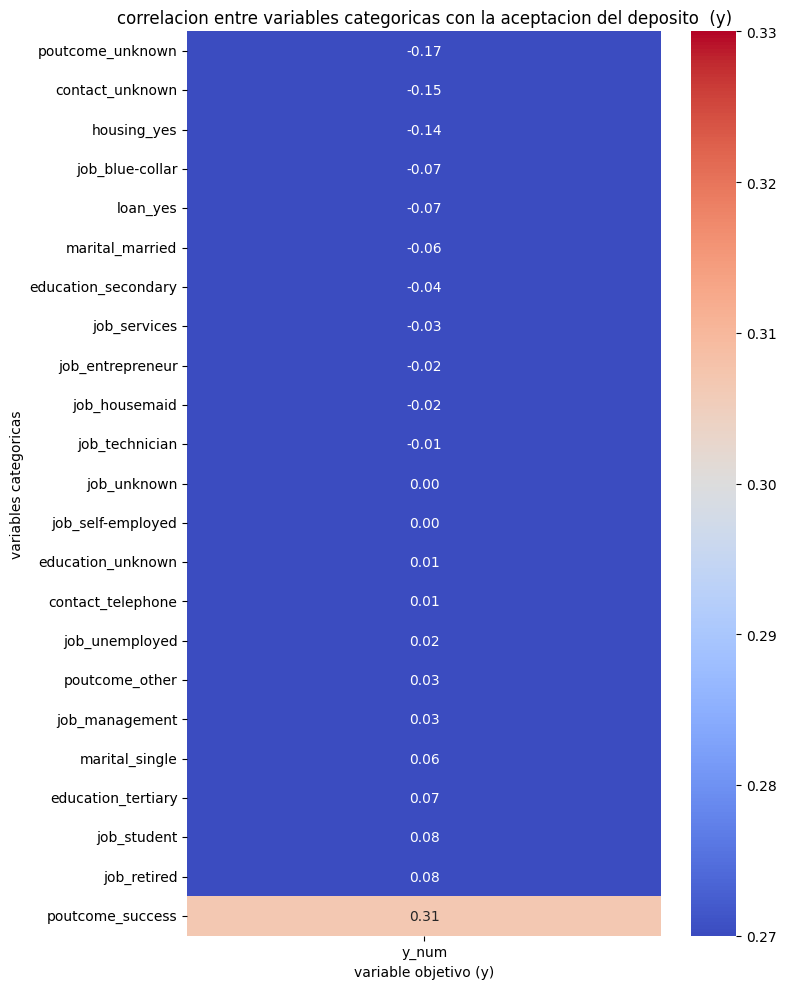

In [ ]:
df_analisis=df.copy()
df_analisis["y_num"]=(df_analisis["y"]=='yes').astype(int)
variables_categoricas = ['education', 'job', 'marital', 'housing', 'loan', 'contact', 'poutcome']
df_encoded=pd.get_dummies(df_analisis[variables_categoricas],drop_first=True)
df_encoded["y_num"]=df_analisis["y_num"]

corr_y = df_encoded.corr()[['y_num']].drop('y_num').sort_values(by='y_num', ascending=True)

plt.figure(figsize=(8, 10))
sns.heatmap(corr_y,annot=True,fmt=".2f",cmap="coolwarm",cbar=True,vmin=0.3,vmax=0.3)
plt.title("correlacion entre variables categoricas con la aceptacion del deposito  (y)")
plt.xlabel("variable objetivo (y)",fontsize=10)
plt.ylabel("variables categoricas",fontsize=10)
plt.tight_layout()
plt.show()



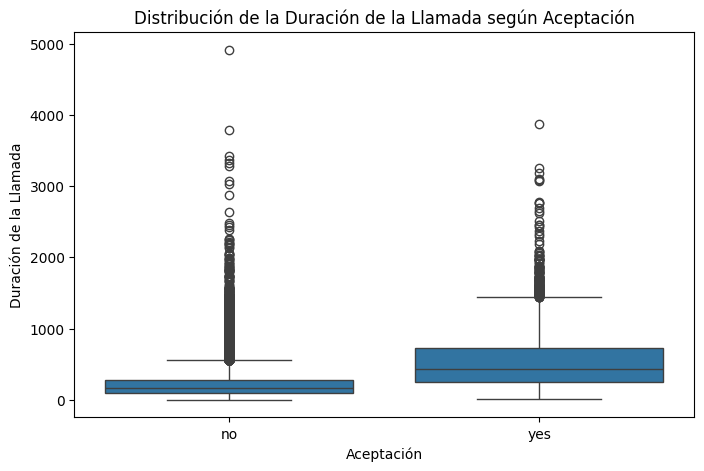

In [ ]:
plt.figure(figsize=(8,5))

sns.boxplot(x="y",y="duration",data=df)
plt.title('Distribución de la Duración de la Llamada según Aceptación')
plt.xlabel('Aceptación')
plt.ylabel('Duración de la Llamada')
plt.show()

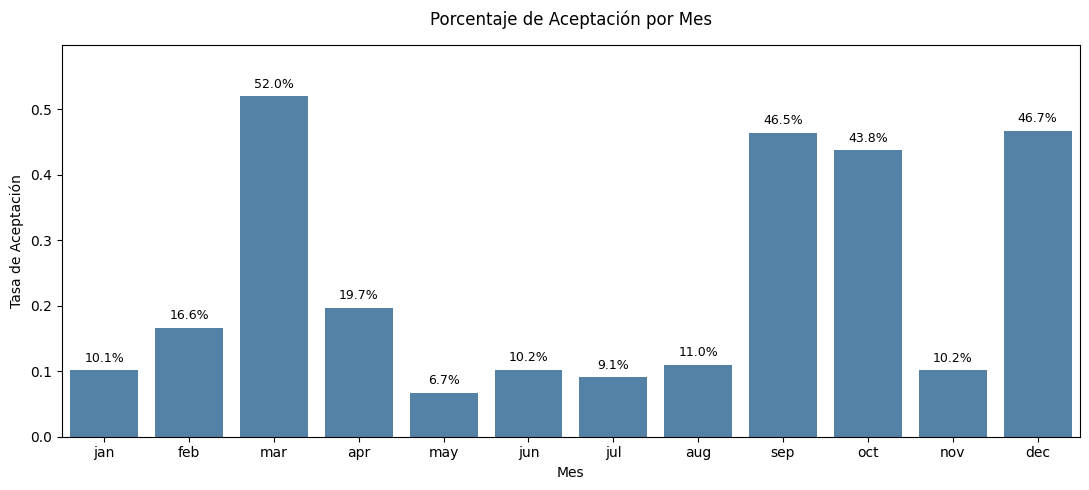

In [ ]:
orden_meses = ['jan', 'feb', 'mar', 'apr', 'may', 'jun', 'jul', 'aug', 'sep', 'oct', 'nov', 'dec']

plt.figure(figsize=(11, 5))
ax = sns.barplot(
    x='month',
    y='y_num',
    data=df_analisis,
    errorbar=None,
    order=orden_meses,
    color='steelblue'
)

for p in ax.patches:
    height = p.get_height()
    if height > 0:
        porcentaje = f"{height * 100:.1f}%"

        ax.annotate(porcentaje,
                    (p.get_x() + p.get_width() / 2., height),
                    ha='center', va='bottom',
                    xytext=(0, 4),
                    textcoords='offset points',
                    fontsize=9)

plt.title('Porcentaje de Aceptación por Mes', fontsize=12, pad=15)
plt.xlabel('Mes', fontsize=10)
plt.ylabel('Tasa de Aceptación', fontsize=10)


plt.ylim(0, max([p.get_height() for p in ax.patches]) * 1.15)

plt.tight_layout()
plt.show()


## **Hallazgos Principales**
se analizo la estructura, distribución y calidad del dataset compuesto por **45,211 registros** correspondientes a campañas de marketing directo de una institución bancaria.

### Calidad y Estructura de los Datos
* **Valores Nulos:** El análisis de nulos (`isnull().sum()`) confirmó que el dataset se encuentra **íntegro y sin valores faltantes (0% de nulos)** en ninguna de sus columnas, lo que evita la necesidad de aplicar imputaciones complejas.
* **Tipos de Variables:** Contiene una mezcla equilibrada de variables numéricas (edad, saldo, duración, campañas previas) y categóricas (empleo, estado civil, educación, tipo de contacto, estado de campañas pasadas y la variable objetivo).

### Variable Objetivo y Desbalance de Clases
* **Distribución del Target (`y`):**
  * `no` (Rechazo): 39,922 registros
  * `yes` (Aceptación): 5,289 registros
* **Hallazgo clave:** Se evidencia un **marcado desbalance de clases**. La tasa de conversión real es de aproximadamente **11.7%**. Este hallazgo justifica técnicamente por qué las métricas tradicionales como el *Accuracy* no son fiables en este escenario y por qué fue necesario implementar técnicas de rebalanceo (como SMOTE) y métricas enfocadas en la minoría (Recall / Precision-Recall).

### Análisis de Variables Numéricas y Estadísticas
* **Saldo (`balance`):** Presenta una dispersión muy alta, con una media de 1,362 euros pero con valores extremos muy marcados (mínimo de -8,019 y máximo de más de 102,000), lo que indica la presencia de asimetría (*skewness*) y outliers que los modelos basados en árboles (como XGBoost) manejan bien, pero que requirieron escalado para los modelos lineales.
* **Duración de la llamada (`duration`):** El gráfico de caja (*boxplot*) demuestra una diferencia clara: los clientes que aceptaron el depósito (`yes`) mantuvieron **conversaciones significativamente más prolongadas** que aquellos que rechazaron la oferta (`no`). *Nota analítica:* Si bien es un fuerte predictor descriptivo, en un escenario de producción real la duración exacta de la llamada solo se conoce al finalizar la misma.

### Estacionalidad y Campañas Anteriores
* **Efecto Estacional (Meses):** La tasa de aceptación mensual varía drásticamente. Meses como **marzo (52.0%)**, **septiembre (46.5%)**, **diciembre (46.7%)** y **octubre (43.8%)** muestran tasas de conversión sumamente altas en comparación con meses de alta densidad de llamadas como **mayo (6.7%)**. Esto indica que el éxito de la campaña está altamente condicionado por la época del año.
* **Historial del Cliente (`poutcome`):** La matriz de correlación y conteos muestra que la variable `poutcome_success` (éxito en la campaña anterior) guarda la correlación positiva más alta con la aceptación del depósito actual (~0.31), confirmando que los clientes fidelizados o con experiencias previas positivas son el segmento con mayor propensión de compra.

## Preprocesamiento y División de los Datos

En esta etapa se acondiciono y se estructuraron los datos para garantizar que los algoritmos de Machine Learning aprendan de forma óptima, manteniendo la integridad estadística de la información.

###  Codificación de Variables Categóricas (One-Hot Encoding)
* **Transformación:** Se aplicó `pd.get_dummies()` con el parámetro `drop_first=True`. Esto convierte todas las variables categóricas en columnas binarias ($0$ y $1$) y elimina la primera categoría de cada atributo para prevenir la **multicolinealidad** (redundancia lineal perfecta), optimizando el comportamiento de los modelos.

###  División del Dataset (Train/Test Split con Estratificación)
* **Proporción:** Se dividieron los datos utilizando un **80% para entrenamiento** (`x_train`, `y_train`) y un **20% para evaluación** (`x_test`, `y_test`), fijando un `random_state=42` para asegurar la reproducibilidad de los resultados.
* **Estratificación (`stratify=y`):** Este parámetro es fundamental dado el desbalance de clases del dataset. Garantiza que tanto el conjunto de entrenamiento como el de prueba conserven la misma proporción exacta de clientes que aceptaron y rechazaron el depósito, evitando sesgos de muestreo.
* **Dimensiones resultantes:**
  * Conjunto de entrenamiento: **36,168 registros** y **42 variables predictoras**.
  * Conjunto de prueba: **9,043 registros** y **42 variables predictoras**.

###  Escalado de Características (StandardScaler y Prevención de Data Leakage)
* **Normalización:** Se implementó `StandardScaler` para estandarizar las variables numéricas, transformándolas para que posean una media de $0$ y una desviación estándar de $1$.
* **Buena práctica técnica:** El escalador se ajustó **exclusivamente con los datos de entrenamiento** mediante `fit_transform(x_train)`, y posteriormente se aplicó esa misma transformación al conjunto de prueba usando únicamente `transform(x_test)`. Esta distinción es crítica para evitar la **fuga de datos (*data leakage*)**, asegurando que el modelo no obtenga información indirecta del conjunto de test antes de ser evaluado.

In [ ]:
df_procesado = pd.get_dummies(df_analisis, drop_first=True)
x = df_procesado.drop(columns=["y_num", "y_yes"])
y=df_procesado["y_num"]

In [ ]:
x_train,x_test,y_train,y_test=train_test_split(
    x,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("datos de entrenamiento",x_train.shape)
print("datos de prueba",x_test.shape)

datos de entrenamiento (36168, 42)
datos de prueba (9043, 42)


In [ ]:
scaler=StandardScaler()

x_train_scaled=scaler.fit_transform(x_train)
x_test_scaled=scaler.transform(x_test)

## Modelo 1: Regresión Logística (Línea Base / Baseline)

Se creó un modelo de Regresión Logística con el objetivo de recomendar al área de marketing aquellos clientes con mayor probabilidad de aceptar el depósito a plazo fijo, reduciendo así el costo económico y de tiempo que conllevan las llamadas innecesarias.

### Configuración y Entrenamiento
* **Parámetros clave:** Se configuró el modelo con `class_weight='balanced'` para contrarrestar el desbalance de clases del dataset, permitiendo que el algoritmo penalice de mayor forma los errores en la clase minoritaria (clientes que sí aceptan).
* **Entrenamiento:** El modelo convergió correctamente sobre el conjunto de datos escalado (`x_train_scaled`).

###  Evaluación y Resultados
Al evaluar el modelo con el conjunto de prueba (`x_test_scaled`), se obtuvieron las siguientes métricas:
* **Accuracy General:** 85% ($0.846$), lo cual aparenta ser un rendimiento excelente a simple vista.
* **Clase Mayoritaria (`0` - No suscripción):** Mantiene una **precisión muy alta ($0.97$)** y un buen **recall ($0.85$)**, lo que indica que el modelo identifica con gran facilidad a los clientes que rechazarán la oferta.
* **Clase Minoritaria (`1` - Suscripción / Clientes Potenciales):**
  * Se logró un **Recall alto del 81%** (gracias al balanceo de pesos), lo que significa que el modelo es capaz de capturar a la gran mayoría de los clientes reales interesados.
  * Sin embargo, la **Precisión se ubicó en un nivel bajo ($42\%$)**. Esto se traduce en una cantidad importante de falsos positivos: el modelo predice que muchos clientes aceptarán cuando en realidad no lo harán, lo que generaría llamadas de marketing en vano.

### Conclusión de la Línea Base y Siguientes Pasos
Este modelo de Regresión Logística actúa como nuestra **línea base (*baseline*)**. Demuestra ser un punto de partida útil al capturar patrones lineales, pero evidencia las limitaciones de un modelo lineal simple ante un problema con clases altamente desbalanceadas.

Para optimizar los resultados —especialmente para **elevar la precisión de la clase minoritaria** y reducir los falsos positivos sin sacrificar la capacidad de detección—, en las siguientes secciones se implementarán técnicas de sobremuestreo como **SMOTE** y modelos de ensamble más potentes como **XGBoost**.

In [ ]:
modelo=LogisticRegression(
    max_iter=1000,
    random_state=42,
    class_weight="balanced"
)
modelo.fit(x_train_scaled,y_train)
print("Modelo entrenado correctamente.")

Modelo entrenado correctamente.


In [ ]:
y_pred=modelo.predict(x_test_scaled)

print("prediciones")
print(y_pred)

print("\nValores reales:")
print(y_test.values)

prediciones
[0 0 0 ... 0 0 0]

Valores reales:
[0 0 0 ... 0 0 0]


In [ ]:
accuracy=accuracy_score(y_test,y_pred)

print("accuracy :",round(accuracy,3))

accuracy : 0.846


In [ ]:
matriz=confusion_matrix(y_test,y_pred)

print(matriz)

[[6789 1196]
 [ 197  861]]


In [ ]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.97      0.85      0.91      7985
           1       0.42      0.81      0.55      1058

    accuracy                           0.85      9043
   macro avg       0.70      0.83      0.73      9043
weighted avg       0.91      0.85      0.87      9043



In [ ]:
probabilidades=modelo.predict_proba(x_test_scaled)
print("Primeros 5 casos:")
print()

for i in range(5):
  print(
      f"caso{i+1}:"
      f"exito ={probabilidades[i][1]:.2%} | "
      f"fracaso ={probabilidades [i][0]:.2%}"
  )

Primeros 5 casos:

caso1:exito =3.13% | fracaso =96.87%
caso2:exito =3.97% | fracaso =96.03%
caso3:exito =7.89% | fracaso =92.11%
caso4:exito =1.62% | fracaso =98.38%
caso5:exito =18.46% | fracaso =81.54%


## Modelo 2: Random Forest (Ensamble de Árboles de Decisión)

Tras evaluar la línea base con Regresión Logística, se decidió implementar un modelo de **Random Forest** (`RandomForestClassifier`). Al tratarse de un algoritmo basado en ensambles de árboles de decisión, tiene la capacidad de capturar relaciones no lineales complejas entre las variables sin requerir suposiciones lineales estrictas.

### Configuración y Entrenamiento
* **Parámetros clave:**
  * `n_estimators=100`: Se construyó un bosque compuesto por $100$ árboles de decisión independientes para mejorar la estabilidad y generalización de las predicciones.
  * `class_weight='balanced'`: Se mantuvo esta configuración para compensar el fuerte desbalance de clases del dataset original.
* **Entrenamiento:** El modelo fue entrenado exitosamente utilizando los datos escalados (`x_train_scaled`).

###  Evaluación y Resultados
Al evaluar el modelo con el conjunto de prueba (`x_test_scaled`), se obtuvieron las siguientes métricas:
* **Accuracy General:** **90.4%** ($0.904$), mostrando una mejora notable en la precisión global respecto al modelo lineal anterior.
* **Clase Mayoritaria (`0` - No suscripción):** Presenta un comportamiento sobresaliente con una **precisión del 92%** y un **recall del 98%**, identificando de manera casi perfecta a los clientes desinteresados.
* **Clase Minoritaria (`1` - Suscripción / Clientes Potenciales):**
  * **Precisión:** Subió significativamente hasta el **69%** ($0.69$). Esto representa una mejora sustancial frente al $42\%$ de la Regresión Logística, lo que significa que **cuando el modelo predice que un cliente aceptará, es correcto un 70% de las veces**, reduciendo drásticamente las llamadas de marketing erróneas o falsos positivos.
  * **Recall:** Disminuyó al **33%** ($0.33$). El modelo se vuelve más conservador, dejando pasar a una mayor cantidad de clientes reales interesados (aumentando los falsos negativos).

### Análisis y Conclusiones de Negocio
* **El compromiso (Trade-off):** Random Forest logra limpiar los falsos positivos con éxito (eleva la precisión de la clase objetivo al 69%), pero a costa de perder sensibilidad (*recall* bajo). En una campaña de marketing, esto significa que el banco llamará a menos gente por error, pero también se perderá a muchos clientes potenciales que habrían aceptado el depósito.
* **Siguientes pasos:** Dado que el modelo presenta un *recall* limitado en la clase minoritaria, el siguiente paso lógico es abordar el desbalance desde la raíz de los datos. Por ello, **antes de entrenar un modelo final avanzado, se aplicará la técnica de oversampling SMOTE** para equilibrar las clases de forma sintética, permitiendo alimentar posteriormente a un clasificador de gradiente potenciado (**XGBoost**) para maximizar el rendimiento global de la campaña

In [ ]:
modelo_rf=RandomForestClassifier(
                              n_estimators=100,
                              class_weight="balanced",
                              random_state=42
                              )
modelo_rf.fit(x_train_scaled,y_train)

y_pred_rf=modelo_rf.predict(x_test_scaled)

accuracy_rf=accuracy_score(y_test,y_pred_rf)
print("accuracy del modelo random forest:",round(accuracy_rf,3),"\n")

print("matriz de confusion")
print(confusion_matrix(y_test,y_pred_rf))

print("\nReporte de clasificación")
print(classification_report(y_test,y_pred_rf))


accuracy del modelo random forest: 0.904 

matriz de confusion
[[7831  154]
 [ 714  344]]

Reporte de clasificación
              precision    recall  f1-score   support

           0       0.92      0.98      0.95      7985
           1       0.69      0.33      0.44      1058

    accuracy                           0.90      9043
   macro avg       0.80      0.65      0.69      9043
weighted avg       0.89      0.90      0.89      9043



## . Manejo Avanzado del Desbalance: SMOTE y Reentrenamiento con Random Forest

Para solucionar la baja sensibilidad (*recall*) que presentaba el modelo de Random Forest anterior en la clase minoritaria, se implementó la técnica de oversampling **SMOTE** (*Synthetic Minority Over-sampling Technique*), buscando equilibrar el espacio de características antes de entrenar nuevamente el algoritmo.

### Aplicación de SMOTE en el Conjunto de Entrenamiento
* **Configuración:** Se instanció SMOTE con `random_state=42` para garantizar la reproducibilidad de la generación de datos sintéticos.
* **Resultado del Remuestreo:**
  * Las dimensiones del conjunto de entrenamiento pasaron de **36,168 registros** a **63,874 registros** ($42$ variables predictoras).
  * Se logró un **balance perfecto de clases (50/50)** en el set de entrenamiento: exactamente **31,937 instancias** para la clase `0` (no suscripción) y **31,937 instancias** para la clase `1` (suscripción).
* **Prevención de Data Leakage:** Al igual que en las etapas previas, SMOTE se aplicó **únicamente sobre `x_train_scaled` e `y_train`**, manteniendo el conjunto de prueba (`x_test_scaled`) totalmente virgen para evaluar el rendimiento real.

###  Reentrenamiento y Evaluación de Random Forest con SMOTE
Tras alimentar al modelo con los datos balanceados mediante SMOTE, se evaluó con el conjunto de prueba original, obteniendo los siguientes resultados:

* **Accuracy General:** **89.9%** ($0.90$), manteniéndose en un nivel global sumamente alto.
* **Clase Mayoritaria (`0` - No suscripción):** Mantiene un desempeño sobresaliente con una **precisión del 95%** y un **recall del 94%**.
* **Clase Minoritaria (`1` - Suscripción / Clientes Potenciales):**
  * **Precisión:** Se situó en el **56%** ($0.56$).
  * **Recall (Sensibilidad):** Experimentó una **mejora drástica y muy positiva**, pasando de un escaso $33\%$ en el modelo anterior sin SMOTE a un **59%** ($0.59$).

###  Análisis e Impacto de Negocio
* **Solución al trade-off anterior:** Al aplicar SMOTE, el modelo dejó de ser tan conservador. Si bien la precisión bajó ligeramente respecto al Random Forest puro (del 69% al 56%), **el recall subió del 33% al 59%**.
* **Interpretación para el Banco:** Esto significa que el modelo ahora es capaz de capturar a **casi 6 de cada 10 clientes reales interesados** en el depósito a plazo fijo (en lugar de perder a la gran mayoría como ocurría antes), logrando un balance mucho más realista y útil para una campaña de marketing directo.
* **Siguientes pasos:** Con este notable avance en la capacidad de detección gracias a SMOTE, el siguiente objetivo es llevar este flujo a un modelo de gradiente potenciado avanzado (**XGBoost**) para evaluar si es posible exprimir aún más la precisión y el rendimiento global del sistema.

In [ ]:
smote=SMOTE(random_state=42)

In [ ]:
x_train_smote,y_train_smote=smote.fit_resample(x_train_scaled,y_train)

print(f"Dimensiones de X_train antes de SMOTE: {x_train_scaled.shape}")
print(f"Dimensiones de X_train después de SMOTE: {x_train_smote.shape}")
print(
    "Conteo de clases en y_train_smote:",
    pd.Series(y_train_smote).value_counts().to_dict(),
)

Dimensiones de X_train antes de SMOTE: (36168, 42)
Dimensiones de X_train después de SMOTE: (63874, 42)
Conteo de clases en y_train_smote: {0: 31937, 1: 31937}


In [ ]:
modelo_rf_smote=RandomForestClassifier(
                                    n_estimators=100,
                                    random_state=42
                                    )

modelo_rf_smote.fit(x_train_smote,y_train_smote)

y_pred_rf_smote=modelo_rf_smote.predict(x_test_scaled)

accuracy_rf_smote=accuracy_score(y_test,y_pred_rf_smote)

print("accuracy del modelo random forest:",round(accuracy_rf_smote,3),"\n")

print("matriz de confusion")

print(confusion_matrix(y_test,y_pred_rf_smote))

print("\nReporte de clasificación")
print(classification_report(y_test,y_pred_rf_smote))


accuracy del modelo random forest: 0.899 

matriz de confusion
[[7502  483]
 [ 434  624]]

Reporte de clasificación
              precision    recall  f1-score   support

           0       0.95      0.94      0.94      7985
           1       0.56      0.59      0.58      1058

    accuracy                           0.90      9043
   macro avg       0.75      0.76      0.76      9043
weighted avg       0.90      0.90      0.90      9043



##  Modelo 4: XGBoost (Extreme Gradient Boosting) y Evaluación Final

Como etapa final de modelado predictivo, se implementó un algoritmo de gradiente potenciado **XGBoost** (`XGBClassifier`), ampliamente reconocido por su gran desempeño en problemas tabulares complejos.

###  Configuración y Entrenamiento
* **Balanceo de Pesos (`scale_pos_weight`):** Se calculó dinámicamente la proporción de clases negativas frente a positivas en el conjunto de entrenamiento (`neg_count / pos_count`) para asignárselo al parámetro `scale_pos_weight`. Esto permite penalizar de forma inteligente los errores en la clase minoritaria sin requerir oversampling artificial en este paso.
* **Entrenamiento:** El modelo procesó con éxito los datos estructurados y escalados (`x_train_scaled`).

###  Métricas y Rendimiento en el Conjunto de Prueba
Al evaluar el modelo con `x_test_scaled`, se obtuvieron métricas de alto rendimiento:
* **Accuracy General:** **87.3%** ($0.873$).
* **Clase Mayoritaria (`0` - No suscripción):** Precisión del **97%** y Recall del **88%**.
* **Clase Minoritaria (`1` - Clientes Potenciales / Suscripción):**
  * **Recall (Sensibilidad):** Alcanzó un impresionante **82%** ($0.82$). El modelo es capaz de capturar a más de **8 de cada 10 clientes reales** que aceptarán el depósito.
  * **Precisión:** Se ubicó en el **48%** ($0.48$), logrando un balance competitivo que reduce considerablemente las llamadas perdidas respecto a los modelos iniciales.

---

##  Evaluación Visual y Curvas de Rendimiento

###  Curva ROC-AUC y Curva Precision-Recall
* **Curva ROC (Área bajo la curva):** El modelo obtuvo un **AUC de 0.927**, lo que demuestra una capacidad de discriminación excelente y robusta entre clientes interesados y no interesados, independientemente del umbral de decisión seleccionado.
* **Curva Precision-Recall:** Permite visualizar el compromiso (*trade-off*) entre precisión y cobertura, evidenciando que XGBoost mantiene un comportamiento estable ideal para ajustar las campañas comerciales según la disponibilidad de presupuesto del banco.

---

##  Importancia de Variables (*Feature Importance*)

Analizar las importancias internas de XGBoost permite comprender qué factores determinan que un cliente decida contratar un depósito a plazo fijo. Según el gráfico de las **Top 10 variables más influyentes**:

1. **`poutcome_success` (16.1%):** Es el factor determinante número uno. Demuestra que haber tenido éxito en una campaña de marketing previa es el mejor predictor de que el cliente repetirá la compra (fidelización).
2. **`contact_unknown` (14.0%):** La falta de registro previo o el canal de comunicación desconocido influye de manera notable en la dinámica predictiva del modelo.
3. **Estacionalidad Mensual (`month_mar`: 6.9%, `month_jul`: 4.6%, etc.):** Los meses específicos —con especial peso en **marzo**, julio, octubre, noviembre, agosto y junio— confirman que la temporalidad de la campaña impacta drásticamente en la tasa de conversión.
4. **`duration` (5.2%):** La duración de la llamada se mantiene como un indicador descriptivo clave de la profundidad e interés de la conversación comercial.
5. **`housing_yes` (4.3%):** Contar con un préstamo hipotecario activo condiciona el perfil financiero y la propensión a aceptar productos de ahorro a plazo fijo.



In [ ]:
neg_count = (y_train == 0).sum()
pos_count = (y_train == 1).sum()
scale_weight = neg_count / pos_count

In [ ]:
modelo_xgb = XGBClassifier(
    scale_pos_weight=scale_weight,
    random_state=42,
    eval_metric="logloss",
)

modelo_xgb.fit(x_train_scaled, y_train)
print("Modelo XGBoost entrenado correctamente.\n")

y_pred_xgb = modelo_xgb.predict(x_test_scaled)
y_prob_xgb = modelo_xgb.predict_proba(x_test_scaled)[:, 1]

print(f"Accuracy de XGBoost: {round(accuracy_score(y_test, y_pred_xgb), 3)}")
print("\nMatriz de Confusión:")
print(confusion_matrix(y_test, y_pred_xgb))
print("\nReporte de Clasificación:")
print(classification_report(y_test, y_pred_xgb))

Modelo XGBoost entrenado correctamente.

Accuracy de XGBoost: 0.873

Matriz de Confusión:
[[7032  953]
 [ 192  866]]

Reporte de Clasificación:
              precision    recall  f1-score   support

           0       0.97      0.88      0.92      7985
           1       0.48      0.82      0.60      1058

    accuracy                           0.87      9043
   macro avg       0.72      0.85      0.76      9043
weighted avg       0.92      0.87      0.89      9043



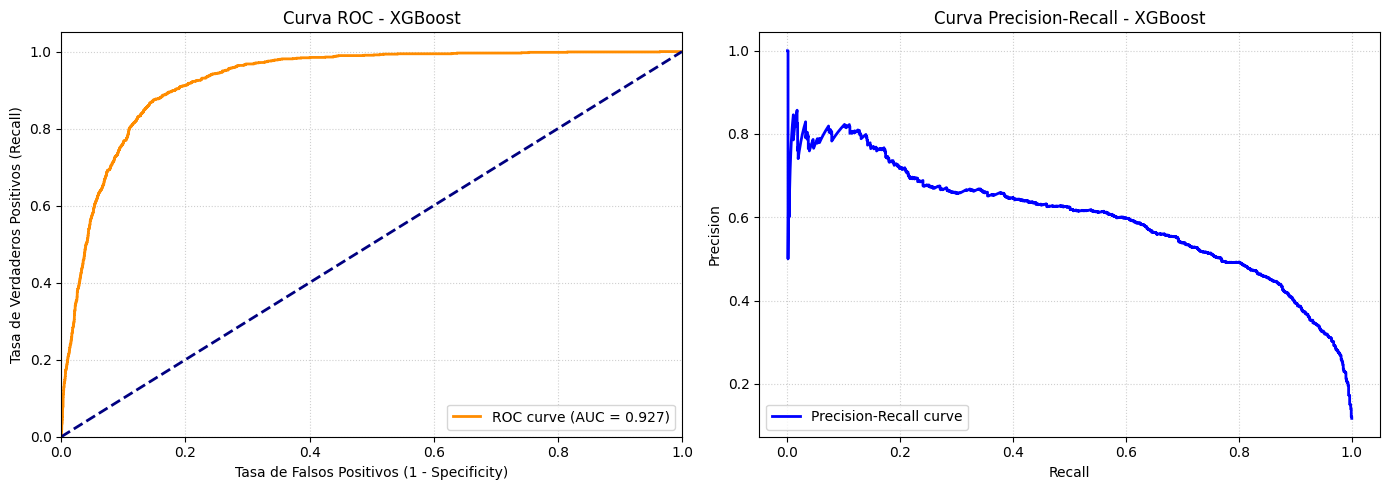

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))


fpr, tpr, _ = roc_curve(y_test, y_prob_xgb)
roc_auc = auc(fpr, tpr)
axes[0].plot(
    fpr,
    tpr,
    color="darkorange",
    lw=2,
    label=f"ROC curve (AUC = {roc_auc:.3f})",
)
axes[0].plot([0, 1], [0, 1], color="navy", lw=2, linestyle="--")
axes[0].set_xlim([0.0, 1.0])
axes[0].set_ylim([0.0, 1.05])
axes[0].set_xlabel("Tasa de Falsos Positivos (1 - Specificity)")
axes[0].set_ylabel("Tasa de Verdaderos Positivos (Recall)")
axes[0].set_title("Curva ROC - XGBoost")
axes[0].legend(loc="lower right")
axes[0].grid(True, linestyle=":", alpha=0.6)


precision, recall, _ = precision_recall_curve(y_test, y_prob_xgb)
axes[1].plot(
    recall, precision, color="blue", lw=2, label="Precision-Recall curve"
)
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].set_title("Curva Precision-Recall - XGBoost")
axes[1].legend(loc="lower left")
axes[1].grid(True, linestyle=":", alpha=0.6)

plt.tight_layout()
plt.show()

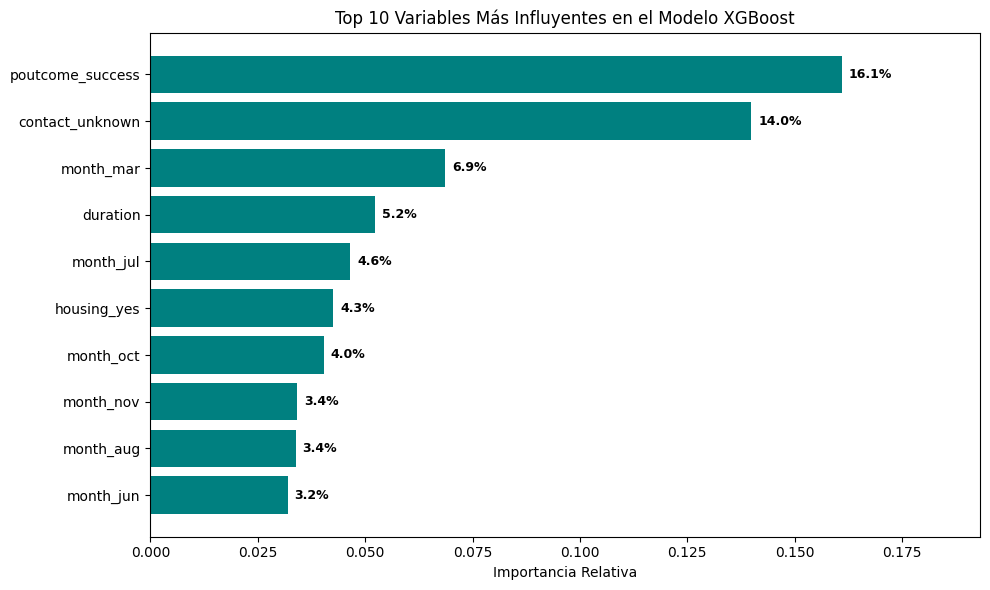

In [ ]:
importantes=modelo_xgb.feature_importances_
feature_names= df_procesado.drop(columns=["y","y_num","y_yes"],errors="ignore").columns

df_importancia=pd.DataFrame({
    "feature":feature_names,
    "importancia":importantes
}).sort_values(by="importancia",ascending=False)

df_top10 = df_importancia.head(10).iloc[::-1]

fig, ax = plt.subplots(figsize=(10, 6))

bars = ax.barh(
    df_top10["feature"],
    df_top10["importancia"],
    color="teal",
)

for bar in bars:
  width = bar.get_width()
  porcentaje = f"{width * 100:.1f}%"
  ax.annotate(
      porcentaje,
      xy=(
          width,
          bar.get_y() + bar.get_height() / 2,
      ),
      xytext=(5, 0),
      textcoords="offset points",
      ha="left",
      va="center",
      fontsize=9,
      fontweight="bold",
      color="black",
  )

ax.set_title("Top 10 Variables Más Influyentes en el Modelo XGBoost")
ax.set_xlabel("Importancia Relativa")
ax.set_xlim(0, df_top10["importancia"].max() * 1.2)

plt.tight_layout()
plt.show()

##  Conclusiones Generales y Recomendaciones Estratégicas (Versión Ampliada)

El desarrollo de este proyecto permitió estructurar un pipeline completo de Machine Learning —desde el Análisis Exploratorio de Datos (EDA) y la prevención de fugas de información (*data leakage*), hasta la evaluación comparativa de múltiples algoritmos y técnicas de rebalanceo—. El modelo final de **XGBoost**, optimizado mediante pesos de clase, logró solucionar con éxito el desafío del fuerte desbalance del dataset ($88\%$ frente a $11.7\%$), alcanzando un **AUC de 0.927** y un **Recall del 82%** en la clase minoritaria.

A partir del análisis cuantitativo y de la importancia de variables (*Feature Importance*), se desprenden las siguientes recomendaciones tácticas y estratégicas para el departamento de marketing y la gerencia de la institución financiera:

###  Recomendaciones Tácticas para la Campaña Comercial

1. **Priorización de Leads por Historial Previo (`poutcome_success`):**
   * *Hallazgo:* El éxito en campañas pasadas es el predictor más fuerte de conversión ($16.1\%$ de importancia).
   * *Acción:* El equipo de marketing debe crear una **segmentación prioritaria exclusiva** para aquellos clientes que ya respondieron positivamente en el pasado. Su probabilidad de recompra es exponencialmente mayor, lo que garantiza un Retorno de Inversión (ROI) inmediato.

2. **Estacionalidad y Ventanas Temporales Óptimas (`month_mar`, `month_jul`, etc.):**
   * *Hallazgo:* Meses como **marzo**, **julio**, **octubre** y **diciembre** muestran tasas de conversión drásticamente superiores en comparación con periodos masivos como mayo.
   * *Acción:* Se recomienda **redistribuir el presupuesto publicitario y la intensidad de llamadas** de manera estacional. Concentrar los esfuerzos de llamadas en los meses de alta propensión evita la fatiga del cliente y optimiza las horas hombre del equipo de telemarketing.

3. **Optimización de Canales de Contacto (`contact_unknown`):**
   * *Hallazgo:* El canal de comunicación o el estado de registro desconocido influye fuertemente en el modelo ($14\%$).
   * *Acción:* Es imperativo que el departamento de operaciones de datos limpie y actualice los registros de contacto en el CRM. Contar con números de teléfono actualizados y canales preferentes identificados incrementará la efectividad de las llamadas en frío.

4. **Gestión Estratégica del Tiempo de Conversación (`duration`):**
   * *Hallazgo:* Si bien la duración de la llamada es un indicador posterior al evento, guarda relación directa con el interés del cliente.
   * *Acción:* Capacitar a los agentes de call center en técnicas de retención y propuesta de valor rápida durante los primeros minutos, ya que las llamadas más extensas convergen significativamente más en depósitos a plazo.

5. **Alineación con Productos Financieros Existentes (`housing_yes`):**
   * *Hallazgo:* Los clientes con préstamos hipotecarios activos tienen un comportamiento financiero diferenciado frente al ahorro.
   * *Acción:* Diseñar ofertas cruzadas (*cross-selling*) combinadas; por ejemplo, ofrecer el depósito a plazo fijo como una opción complementaria de diversificación para clientes que ya mantienen compromisos crediticios con la entidad.

---

###  Impacto de Negocio y Eficiencia Operativa
* **Reducción de Costos Operativos:** Al pasar de modelos de línea base con baja precisión a un clasificador XGBoost afinado, el banco dejará de gastar recursos económicos y operativos llamando a miles de clientes fríos o desinteresados (reduciendo drásticamente los falsos positivos).
* **Mitigación del Costo de Oportunidad:** Con un **Recall del 82%**, el modelo asegura que el banco capte a la gran mayoría de los clientes realmente interesados, maximizando los fondos captados para la institución.

